In [2]:
import os
import sys
import numpy as np
import pandas as pd
import nibabel as nib
import nilearn
from nilearn.image import resample_img
from nilearn import plotting
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from nilearn import masking
from natsort import natsorted
import pickle

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import matplotlib.pyplot as plt
from scipy.stats import zscore

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import KFold
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Load MNI mask for ROIs betas

In [3]:
maskDir = 'F:\yujun\projects\data\masks'
maskFile = os.path.join(maskDir, 'MNI152_T1_2mm_brain_mask.nii.gz')
mask = nib.load(maskFile)

In [4]:
mask.get_fdata().shape

(91, 109, 91)

# Resample MNI mask

In [5]:
temp_nii_path = r'F:\yujun\projects\AI_IAPS\GLM_singletrial\\betas\Sub1\\beta_0001.nii'
temp_nii_data = nib.load(temp_nii_path)
# Resample the MNI mask to match the dimensions and voxel size of your NIfTI file
resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
resampled_mask.shape

(79, 95, 79)

# Load Kastner mask

In [6]:
# Load the dictionary from the file
with open('kastner_dict.pkl', 'rb') as f:
    roi_masks = pickle.load(f)


In [7]:
for (k, v) in roi_masks.items():
    print(k, v.get_fdata().shape, np.count_nonzero(v.get_fdata()))

V1v (79, 95, 79) 856
V1d (79, 95, 79) 748
V2v (79, 95, 79) 727
V2d (79, 95, 79) 645
V3v (79, 95, 79) 527
V3d (79, 95, 79) 517
hV4 (79, 95, 79) 328
V3a (79, 95, 79) 554
V3b (79, 95, 79) 263
LO1 (79, 95, 79) 324
LO2 (79, 95, 79) 125
VO1 (79, 95, 79) 153
VO2 (79, 95, 79) 253
IPS (79, 95, 79) 973
PHC1 (79, 95, 79) 175
PHC2 (79, 95, 79) 165


c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\html_stat_map.py:219: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  bg_img = load_mni152_template()
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:545: UserWarning: Casting data from int32 to float32
  warnings.warn("Casting data from %s to %s" % (data.dtype.name, aux))
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:274: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn("Resampling binary images with continuous or "



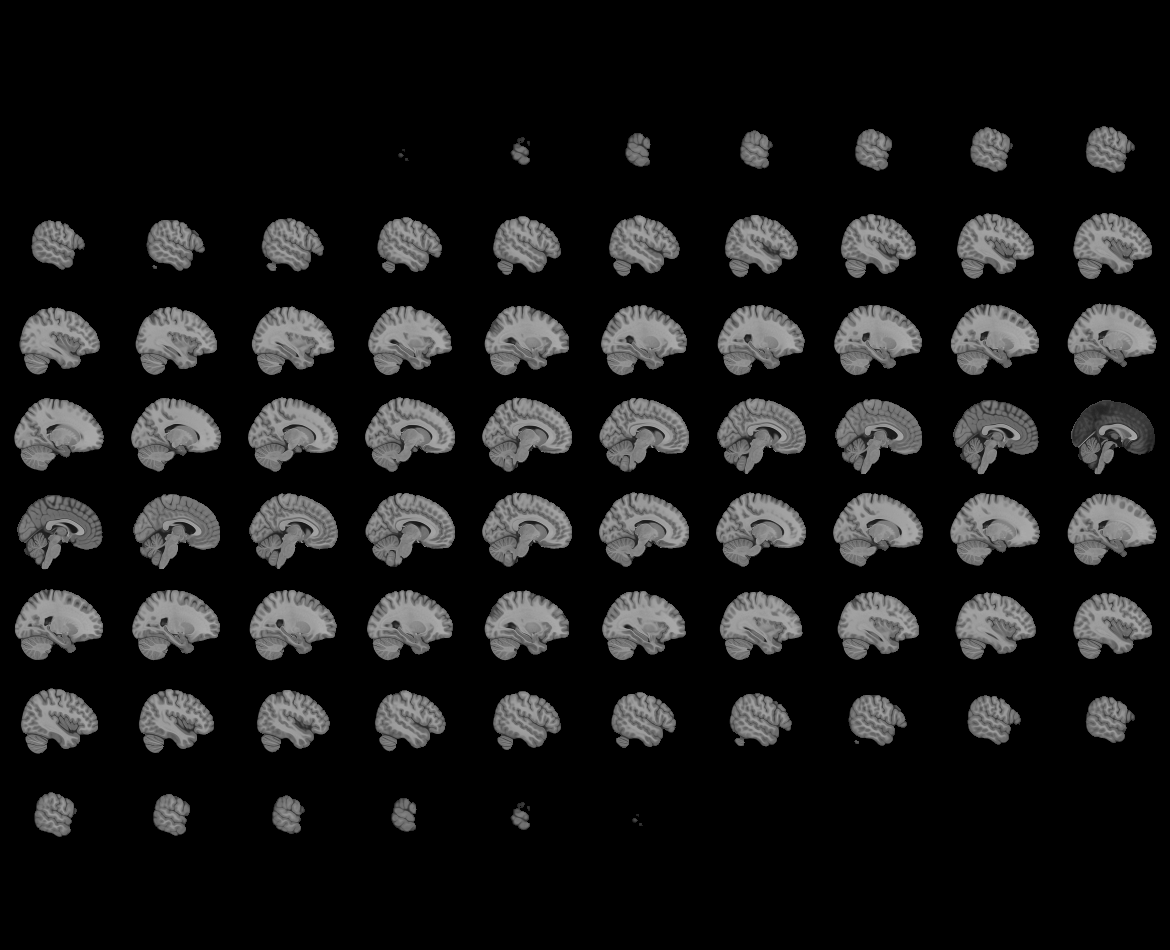
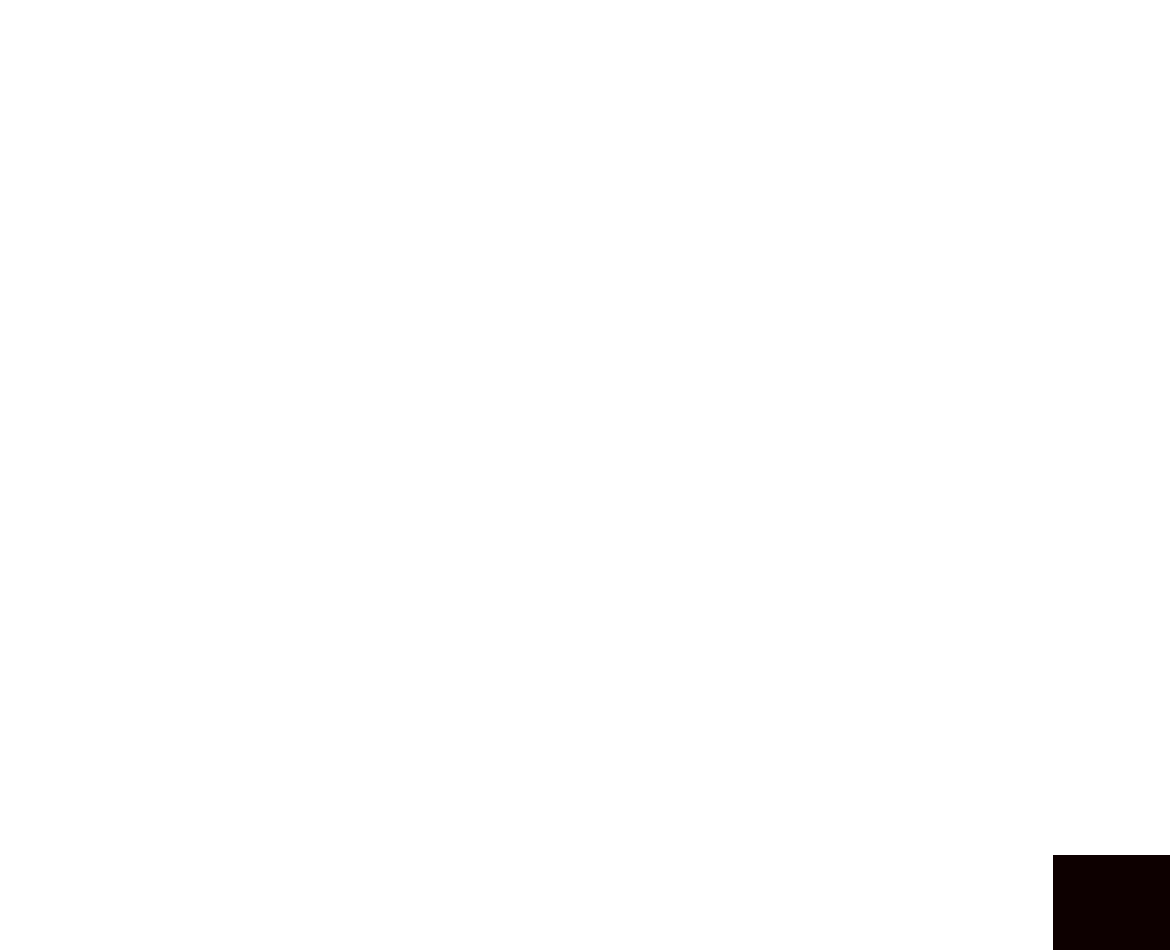

In [12]:
roi = 'V1v'
view = plotting.view_img(roi_masks[roi], title = roi)
view

# Load beta and Z series

In [17]:
# z_series_arr = np.load("./data/z_series_arr.npy")

In [12]:
z_series = np.load("./data/reordered_singletrial_z.npy")

In [13]:
z_series.shape

(7, 600, 79, 95, 79)

#### Check masked z series

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\_utils\niimg.py:63: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



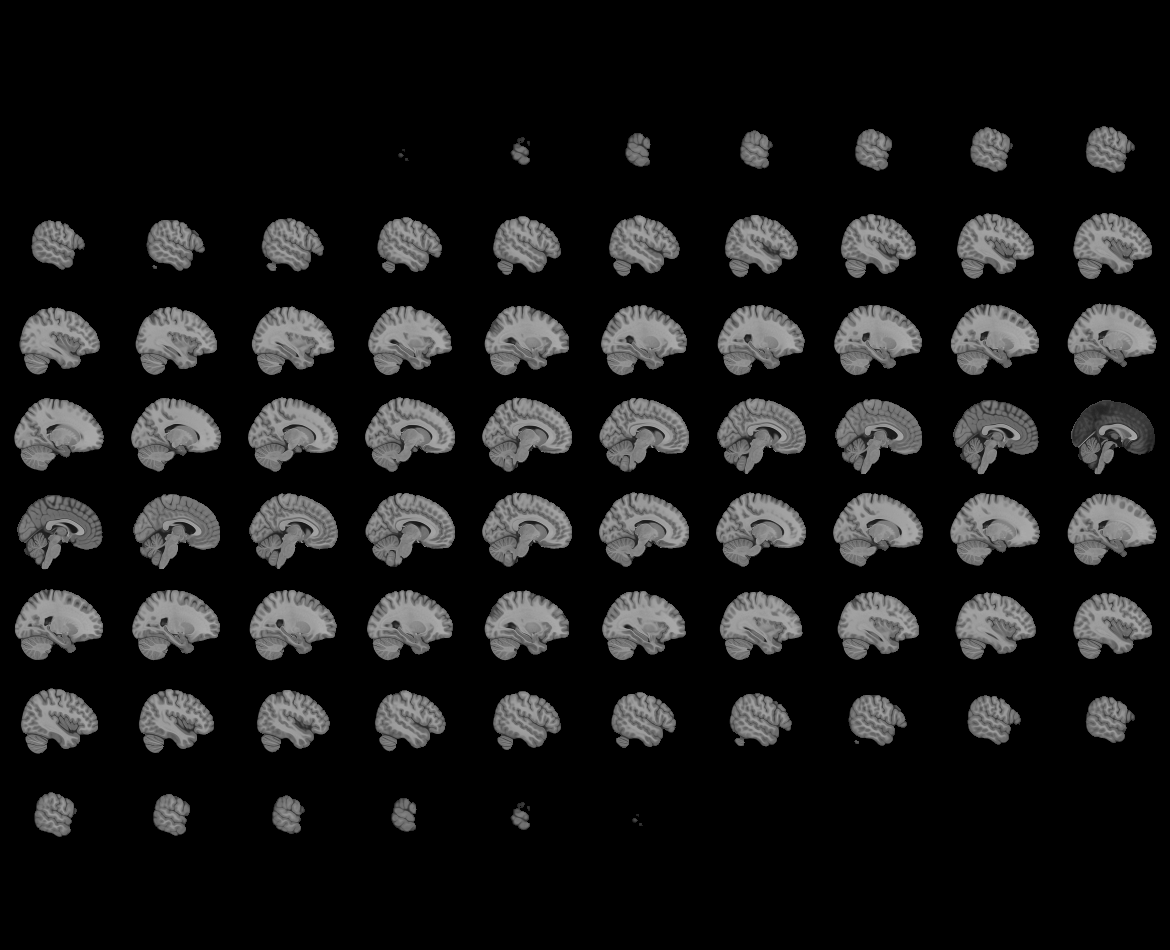
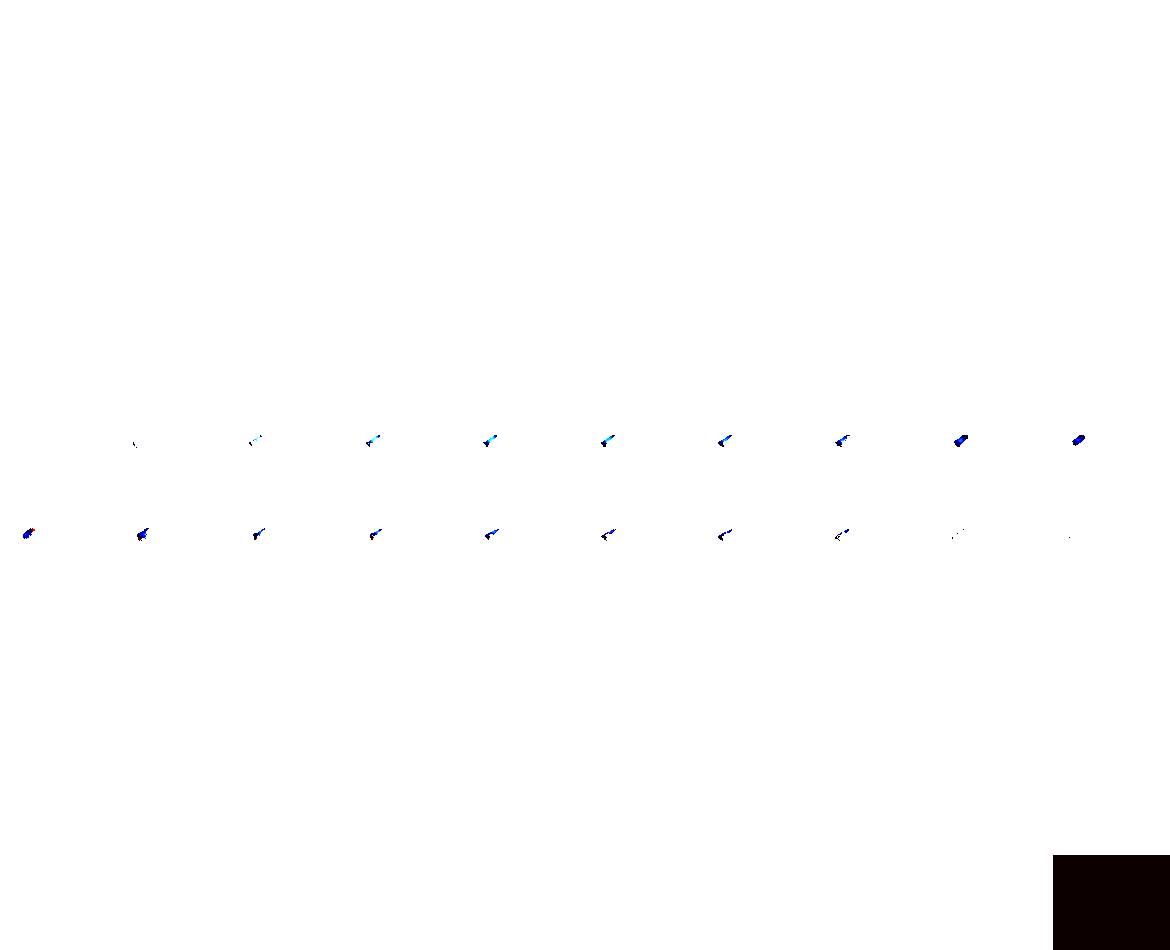

In [16]:
z_series_arr_test = z_series[1,100,:]
z_series_arr_test_1d = z_series_arr_test.flatten()
# z_series_arr_test_1d = z_series_arr_test.flatten(order = 'F')

flat_roi_data = roi_masks['V1v'].get_fdata()
# roi_flat = flat_roi_data.flatten(order='F') # this is the same as reshape(1, -1)
roi_flat = flat_roi_data.flatten()
# roi_flat = flat_roi_data.flatten(order = 'F')
indices = np.where(roi_flat)[0]
roi_betas = np.squeeze(z_series_arr_test_1d)[indices]

test_mask_data = np.empty((79, 95, 79))
test_mask_data[:] = np.nan
test_mask_data_flat = test_mask_data.flatten()
test_mask_data_flat[indices] = roi_betas
# With no F order
from nilearn.image import new_img_like
test_mask_nii = new_img_like(resampled_mask, test_mask_data_flat.reshape(79, 95, 79))
view = plotting.view_img(test_mask_nii)
view


# Load stimuli file

In [9]:
stimuli = pd.read_csv("./stimuli_600trials.csv")
stimuli

,Unnamed: 0,OriginalOrder,img,emotion_type,AI,group
0,0,0,2045_2.jpg,pleasant,YES,pleasantAI
1,1,1,6211_0.jpg,unpleasant,YES,unpleasantAI
2,2,2,5395_2.jpg,neutral,YES,neutralAI
3,3,3,3230_0.jpg,unpleasant,YES,unpleasantAI
4,4,4,2550.jpg,pleasant,NO,pleasant
...,...,...,...,...,...,...
595,595,595,3016_1.jpg,unpleasant,YES,unpleasantAI
596,596,596,9140.jpg,unpleasant,NO,unpleasant
597,597,597,2446.jpg,neutral,NO,neutral
598,598,598,9570_1.jpg,unpleasant,YES,unpleasantAI


In [10]:

# Define the order for sorting
group_order = ['pleasant', 'neutral', 'unpleasant', 'pleasantAI', 'neutralAI', 'unpleasantAI']

# Group beta_series_arr based on 'img' column
unique_imgs = stimuli['img'].unique()

# Create a sorted index based on 'group' column
stimuli_sorted = stimuli.drop_duplicates(subset=['img']).set_index('img')
stimuli_sorted = stimuli_sorted.loc[unique_imgs]
stimuli_sorted['group_order'] = pd.Categorical(stimuli_sorted['group'], categories=group_order, ordered=True)
stimuli_sorted = stimuli_sorted.sort_values('group_order')
stimuli_sorted

,Unnamed: 0,OriginalOrder,emotion_type,AI,group,group_order
img,,,,,,
7451.jpg,93,93,pleasant,NO,pleasant,pleasant
4604.jpg,39,39,pleasant,NO,pleasant,pleasant
4597.jpg,26,26,pleasant,NO,pleasant,pleasant
4601.jpg,41,41,pleasant,NO,pleasant,pleasant
4628.jpg,43,43,pleasant,NO,pleasant,pleasant
...,...,...,...,...,...,...
3051_0.jpg,45,45,unpleasant,YES,unpleasantAI,unpleasantAI
9570_1.jpg,40,40,unpleasant,YES,unpleasantAI,unpleasantAI
9491_0.jpg,68,68,unpleasant,YES,unpleasantAI,unpleasantAI


In [11]:
unique_imgs

array(['2045_2.jpg', '6211_0.jpg', '5395_2.jpg', '3230_0.jpg', '2550.jpg',
       '1510_2.jpg', '2499.jpg', '3016_1.jpg', '2314_0.jpg', '4574_2.jpg',
       '2580_1.jpg', '9140.jpg', '9300_1.jpg', '5470_2.jpg', '2850_1.jpg',
       '5665.jpg', '5779.jpg', '9905_2.jpg', '4505.jpg', '2314.jpg',
       '9140_2.jpg', '9075_0.jpg', '9570.jpg', '1419_2.jpg', '2010.jpg',
       '2550_0.jpg', '4597.jpg', '4601_0.jpg', '3016.jpg', '1640_0.jpg',
       '4180.jpg', '9430.jpg', '5600.jpg', '2446_2.jpg', '3230.jpg',
       '4210_0.jpg', '2300_0.jpg', '5455.jpg', '9491.jpg', '4604.jpg',
       '9570_1.jpg', '4601.jpg', '4001_2.jpg', '4628.jpg', '1205.jpg',
       '3051_0.jpg', '4505_1.jpg', '2540.jpg', '5661.jpg', '1604_2.jpg',
       '5661_0.jpg', '5551.jpg', '2900.1.jpg', '9909.jpg', '7405_0.jpg',
       '2850.jpg', '4150.jpg', '3101.jpg', '6940_2.jpg', '9900.jpg',
       '9300.jpg', '4232.jpg', '1419.jpg', '2540_2.jpg', '2446.jpg',
       '5395.jpg', '5455_2.jpg', '5470.jpg', '9491_0.jpg', '6940.

# Within condition decoding

In [14]:
z_series_arr = z_series.reshape(z_series.shape[0],z_series.shape[1],-1)
z_series_arr.shape

(7, 600, 592895)

In [15]:
z_series_wo_sub3  = np.delete(z_series_arr, 2, axis=0)


In [16]:
z_series_wo_sub3.shape

(6, 600, 592895)

In [17]:
conditions = ['pleasant', 'neutral', 'unpleasant', 'pleasantAI', 'neutralAI', 'unpleasantAI']

In [18]:
decode_names = []
decode_names.append('PL vs Nt, Natrual')
decode_names.append('Up vs Nt, Natrual')
decode_names.append('Pl vs Nt, AI')
decode_names.append('Up vs Nt, AI')

In [21]:
subs =          ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9', 'Sub11', 'Sub12']
selected_subs = ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub9', 'Sub11', 'Sub12']
# Create a mapping from selected_subs to their corresponding index in subs list
selected_indices = [subs.index(sub) for sub in selected_subs]
selected_indices

[0, 1, 2, 3, 4, 5, 6, 8, 9, 10]

### PL-NT, NA

In [19]:
# Specify the two conditions you want to use for decoding
condition1 = 'pleasant'
condition2 = 'neutral'

condition1_idx = conditions.index(condition1)
condition2_idx = conditions.index(condition2)

accuracy_rois = []
for m , (roi_name, roi_mask) in enumerate(roi_masks.items()):
    print(f"Decoding {roi_name}......")
    flat_roi_data = roi_mask.get_fdata()
    # roi_flat = flat_roi_data.flatten(order='F') # this is the same as reshape(1, -1)
    roi_flat = flat_roi_data.flatten()
    indices = np.where(roi_flat)[0]
    data = z_series_wo_sub3[:, :, indices] 

    accuracy_subs = []
    for subject in tqdm(range(data.shape[0])):
        subject_data = data[subject]
        condition1_trials = subject_data[condition1_idx * 100:(condition1_idx + 1) * 100]
        condition2_trials = subject_data[condition2_idx * 100:(condition2_idx + 1) * 100]

        condition1_trials = condition1_trials[:,~np.isnan(condition1_trials[0, :])]
        condition2_trials = condition2_trials[:,~np.isnan(condition2_trials[0, :])]

        # Calculate z-score for condition1_trials and condition2_trials
        # condition1_trials = zscore(condition1_trials, axis=1)
        # condition2_trials = zscore(condition2_trials, axis=1)
        accuracies = []
        for repeat in range(50):
            kf = KFold(n_splits=4, shuffle=True, random_state=repeat)
            condition1_indices = np.arange(condition1_trials.shape[0])
            condition2_indices = np.arange(condition2_trials.shape[0])

            for train_idx, test_idx in kf.split(condition1_indices, condition2_indices):
                train_condition1 = condition1_trials[train_idx]
                train_condition2 = condition2_trials[train_idx]
                test_condition1 = condition1_trials[test_idx]
                test_condition2 = condition2_trials[test_idx]

                # Group the training trials into 3 groups by averaging the first dimension
                train_condition1_averaged_1 = np.array_split(train_condition1, 3, axis=0)
                train_condition1_averaged_2 = [np.mean(group, axis=0) for group in train_condition1_averaged_1]
                train_condition1_averaged = np.array(train_condition1_averaged_2)

                train_condition2_averaged_1 = np.array_split(train_condition2, 3, axis=0)
                train_condition2_averaged_2 = [np.mean(group, axis=0) for group in train_condition2_averaged_1]
                train_condition2_averaged = np.array(train_condition2_averaged_2)

                # Keep the test trials as a single group
                test_condition1_averaged = np.mean(test_condition1, axis=0, keepdims=True)
                test_condition2_averaged = np.mean(test_condition2, axis=0, keepdims=True)

                # Stack the training data along the first axis
                train_data = np.vstack((train_condition1_averaged, train_condition2_averaged))
                train_labels = np.array([1] * len(train_condition1_averaged) + [0] * len(train_condition2_averaged))

                test_data = np.vstack((test_condition1_averaged, test_condition2_averaged))
                test_labels = np.array([1] * test_condition1_averaged.shape[0] + [0] * test_condition2_averaged.shape[0])

                # Replace NaN values with zeros in train and test data
                # train_data = np.nan_to_num(train_data, copy=False)
                # test_data = np.nan_to_num(test_data, copy=False)

                clf = SVC(kernel='linear')
                clf.fit(train_data, train_labels)
                accuracy = clf.score(test_data, test_labels)
                accuracies.append(accuracy)
        accuracy_subs.append(np.mean(accuracies))

    accuracy_rois.append(np.array(accuracy_subs))
accuracy_self_plnt = np.array(accuracy_rois)

Decoding V1v......


  0%|          | 0/6 [1:07:01<?, ?it/s]


KeyboardInterrupt: 

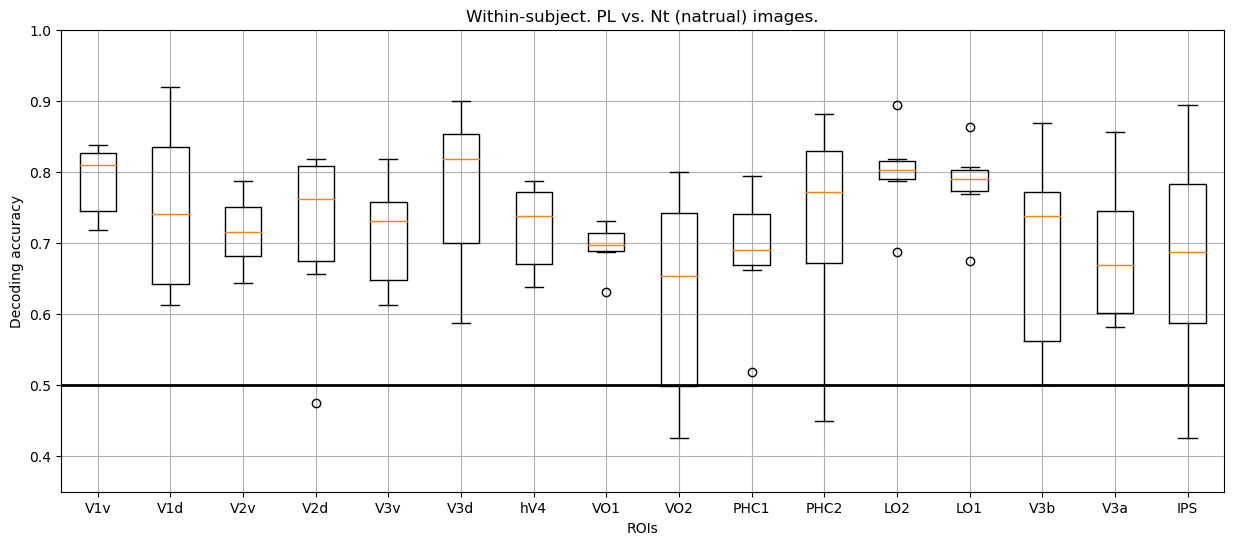

In [31]:
case_id = 0
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(accuracy_self_plnt.T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Within-subject. {decode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 1.0)  # Set the y-axis limits
# Add a thick black line at y=0.5
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

### UP-NT, NA

In [56]:
# Specify the two conditions you want to use for decoding
condition1 = 'unpleasant'
condition2 = 'neutral'

condition1_idx = conditions.index(condition1)
condition2_idx = conditions.index(condition2)

accuracy_rois = []
for m , (roi_name, roi_mask) in enumerate(roi_masks.items()):
    print(f"Decoding {roi_name}......")
    flat_roi_data = roi_mask.get_fdata()
    # roi_flat = flat_roi_data.flatten(order='F') # this is the same as reshape(1, -1)
    roi_flat = flat_roi_data.flatten()
    indices = np.where(roi_flat)[0]
    data = z_series_wo_sub3[:, :, indices] 

    accuracy_subs = []
    for subject in tqdm(range(data.shape[0])):
        subject_data = data[subject]
        condition1_trials = subject_data[condition1_idx * 100:(condition1_idx + 1) * 100]
        condition2_trials = subject_data[condition2_idx * 100:(condition2_idx + 1) * 100]

        condition1_trials = condition1_trials[:,~np.isnan(condition1_trials[0, :])]
        condition2_trials = condition2_trials[:,~np.isnan(condition2_trials[0, :])]

        # Calculate z-score for condition1_trials and condition2_trials
        # condition1_trials = zscore(condition1_trials, axis=1)
        # condition2_trials = zscore(condition2_trials, axis=1)
        accuracies = []
        for repeat in range(50):
            kf = KFold(n_splits=4, shuffle=True, random_state=repeat)
            condition1_indices = np.arange(condition1_trials.shape[0])
            condition2_indices = np.arange(condition2_trials.shape[0])

            for train_idx, test_idx in kf.split(condition1_indices, condition2_indices):
                train_condition1 = condition1_trials[train_idx]
                train_condition2 = condition2_trials[train_idx]
                test_condition1 = condition1_trials[test_idx]
                test_condition2 = condition2_trials[test_idx]

                # Group the training trials into 3 groups by averaging the first dimension
                train_condition1_averaged_1 = np.array_split(train_condition1, 3, axis=0)
                train_condition1_averaged_2 = [np.mean(group, axis=0) for group in train_condition1_averaged_1]
                train_condition1_averaged = np.array(train_condition1_averaged_2)

                train_condition2_averaged_1 = np.array_split(train_condition2, 3, axis=0)
                train_condition2_averaged_2 = [np.mean(group, axis=0) for group in train_condition2_averaged_1]
                train_condition2_averaged = np.array(train_condition2_averaged_2)

                # Keep the test trials as a single group
                test_condition1_averaged = np.mean(test_condition1, axis=0, keepdims=True)
                test_condition2_averaged = np.mean(test_condition2, axis=0, keepdims=True)

                # Stack the training data along the first axis
                train_data = np.vstack((train_condition1_averaged, train_condition2_averaged))
                train_labels = np.array([1] * len(train_condition1_averaged) + [0] * len(train_condition2_averaged))

                test_data = np.vstack((test_condition1_averaged, test_condition2_averaged))
                test_labels = np.array([1] * test_condition1_averaged.shape[0] + [0] * test_condition2_averaged.shape[0])

                # Replace NaN values with zeros in train and test data
                # train_data = np.nan_to_num(train_data, copy=False)
                # test_data = np.nan_to_num(test_data, copy=False)

                clf = SVC(kernel='linear')
                clf.fit(train_data, train_labels)
                accuracy = clf.score(test_data, test_labels)
                accuracies.append(accuracy)
        accuracy_subs.append(np.mean(accuracies))

    accuracy_rois.append(np.array(accuracy_subs))
accuracy_self_upnt = np.array(accuracy_rois)

Decoding V1v......


100%|██████████| 6/6 [00:02<00:00,  2.17it/s]


Decoding V1d......


100%|██████████| 6/6 [00:02<00:00,  2.45it/s]


Decoding V2v......


100%|██████████| 6/6 [00:02<00:00,  2.45it/s]


Decoding V2d......


100%|██████████| 6/6 [00:02<00:00,  2.35it/s]


Decoding V3v......


100%|██████████| 6/6 [00:03<00:00,  1.93it/s]


Decoding V3d......


100%|██████████| 6/6 [00:02<00:00,  2.18it/s]


Decoding hV4......


100%|██████████| 6/6 [00:02<00:00,  2.45it/s]


Decoding VO1......


100%|██████████| 6/6 [00:01<00:00,  3.09it/s]


Decoding VO2......


100%|██████████| 6/6 [00:02<00:00,  2.43it/s]


Decoding PHC1......


100%|██████████| 6/6 [00:01<00:00,  3.05it/s]


Decoding PHC2......


100%|██████████| 6/6 [00:01<00:00,  3.37it/s]


Decoding LO2......


100%|██████████| 6/6 [00:01<00:00,  3.37it/s]


Decoding LO1......


100%|██████████| 6/6 [00:02<00:00,  2.87it/s]


Decoding V3b......


100%|██████████| 6/6 [00:02<00:00,  2.36it/s]


Decoding V3a......


100%|██████████| 6/6 [00:02<00:00,  2.29it/s]


Decoding IPS......


100%|██████████| 6/6 [00:03<00:00,  1.62it/s]


In [63]:
# Specify the two conditions you want to use for decoding
condition1 = 'unpleasant'
condition2 = 'neutral'

condition1_idx = conditions.index(condition1)
condition2_idx = conditions.index(condition2)

accuracy_rois = []
for m , (roi_name, roi_mask) in enumerate(roi_masks.items()):
    print(f"Decoding {roi_name}......")
    flat_roi_data = roi_mask.get_fdata()
    # roi_flat = flat_roi_data.flatten(order='F') # this is the same as reshape(1, -1)
    roi_flat = flat_roi_data.flatten()
    indices = np.where(roi_flat)[0]
    data = z_series_wo_sub3[:, :, indices] 

    accuracy_subs = []
    for subject in tqdm(range(data.shape[0])):
        subject_data = data[subject]
        condition1_trials = subject_data[condition1_idx * 100:(condition1_idx + 1) * 100]
        condition2_trials = subject_data[condition2_idx * 100:(condition2_idx + 1) * 100]

        condition1_trials = condition1_trials[:,~np.isnan(condition1_trials[0, :])]
        condition2_trials = condition2_trials[:,~np.isnan(condition2_trials[0, :])]

        # Calculate z-score for condition1_trials and condition2_trials
        # condition1_trials = zscore(condition1_trials, axis=1)
        # condition2_trials = zscore(condition2_trials, axis=1)
        accuracies = []
        for repeat in range(50):
            kf = KFold(n_splits=4, shuffle=True, random_state=repeat)
            condition1_indices = np.arange(condition1_trials.shape[0])
            condition2_indices = np.arange(condition2_trials.shape[0])

            for train_idx, test_idx in kf.split(condition1_indices, condition2_indices):
                train_condition1 = condition1_trials[train_idx]
                train_condition2 = condition2_trials[train_idx]
                test_condition1 = condition1_trials[test_idx]
                test_condition2 = condition2_trials[test_idx]

                # Group the training trials into 3 groups by averaging the first dimension
                train_condition1_averaged_1 = np.array_split(train_condition1, 3, axis=0)
                train_condition1_averaged_2 = [np.mean(group, axis=0) for group in train_condition1_averaged_1]
                train_condition1_averaged = np.array(train_condition1_averaged_2)

                train_condition2_averaged_1 = np.array_split(train_condition2, 3, axis=0)
                train_condition2_averaged_2 = [np.mean(group, axis=0) for group in train_condition2_averaged_1]
                train_condition2_averaged = np.array(train_condition2_averaged_2)

                # Keep the test trials as a single group
                test_condition1_averaged = np.mean(test_condition1, axis=0, keepdims=True)
                test_condition2_averaged = np.mean(test_condition2, axis=0, keepdims=True)

                # Stack the training data along the first axis
                train_data = np.vstack((train_condition1_averaged, train_condition2_averaged))
                train_labels = np.array([1] * len(train_condition1_averaged) + [0] * len(train_condition2_averaged))

                test_data = np.vstack((test_condition1_averaged, test_condition2_averaged))
                test_labels = np.array([1] * test_condition1_averaged.shape[0] + [0] * test_condition2_averaged.shape[0])

                # Replace NaN values with zeros in train and test data
                # train_data = np.nan_to_num(train_data, copy=False)
                # test_data = np.nan_to_num(test_data, copy=False)

                clf = SVC(kernel='linear')
                clf.fit(train_data, train_labels)
                accuracy = clf.score(test_data, test_labels)
                accuracies.append(accuracy)
        accuracy_subs.append(np.mean(accuracies))

    accuracy_rois.append(np.array(accuracy_subs))
accuracy_self_upnt = np.array(accuracy_rois)

Decoding V1v......


100%|██████████| 6/6 [00:04<00:00,  1.28it/s]


Decoding V1d......


100%|██████████| 6/6 [00:03<00:00,  1.80it/s]


Decoding V2v......


100%|██████████| 6/6 [00:03<00:00,  1.88it/s]


Decoding V2d......


100%|██████████| 6/6 [00:03<00:00,  1.90it/s]


Decoding V3v......


100%|██████████| 6/6 [00:03<00:00,  1.97it/s]


Decoding V3d......


100%|██████████| 6/6 [00:03<00:00,  1.98it/s]


Decoding hV4......


100%|██████████| 6/6 [00:02<00:00,  2.05it/s]


Decoding V3a......


100%|██████████| 6/6 [00:03<00:00,  1.91it/s]


Decoding V3b......


100%|██████████| 6/6 [00:02<00:00,  2.06it/s]


Decoding LO1......


100%|██████████| 6/6 [00:02<00:00,  2.01it/s]


Decoding LO2......


100%|██████████| 6/6 [00:02<00:00,  2.03it/s]


Decoding VO1......


100%|██████████| 6/6 [00:02<00:00,  2.04it/s]


Decoding VO2......


100%|██████████| 6/6 [00:02<00:00,  2.02it/s]


Decoding IPS......


100%|██████████| 6/6 [00:03<00:00,  1.70it/s]


Decoding PHC1......


100%|██████████| 6/6 [00:03<00:00,  1.99it/s]


Decoding PHC2......


100%|██████████| 6/6 [00:02<00:00,  2.15it/s]


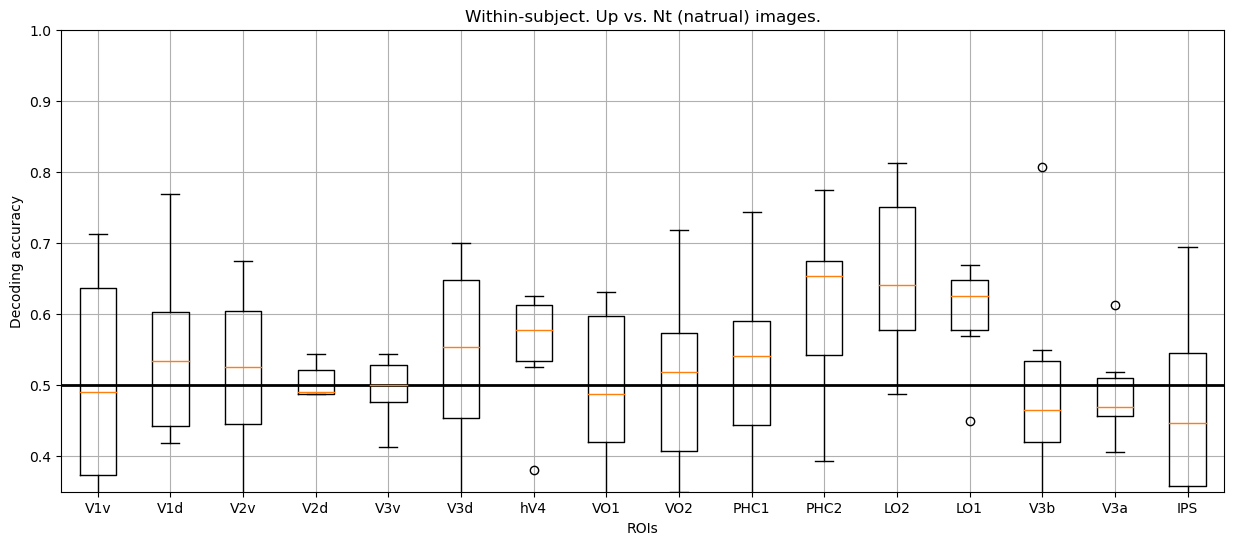

In [48]:
case_id = 1
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(accuracy_rois.T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Within-subject. {decode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 1.0)  # Set the y-axis limits
# Add a thick black line at y=0.5
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

### PL-NT, AI

In [59]:
# Specify the two conditions you want to use for decoding
condition1 = 'pleasantAI'
condition2 = 'neutralAI'

condition1_idx = conditions.index(condition1)
condition2_idx = conditions.index(condition2)

accuracy_rois = []
for m , (roi_name, roi_mask) in enumerate(roi_masks.items()):
    print(f"Decoding {roi_name}......")
    flat_roi_data = roi_mask.get_fdata()
    # roi_flat = flat_roi_data.flatten(order='F') # this is the same as reshape(1, -1)
    roi_flat = flat_roi_data.flatten()
    indices = np.where(roi_flat)[0]
    data = z_series_wo_sub3[:, :, indices] 

    accuracy_subs = []
    for subject in tqdm(range(data.shape[0])):
        subject_data = data[subject]
        condition1_trials = subject_data[condition1_idx * 100:(condition1_idx + 1) * 100]
        condition2_trials = subject_data[condition2_idx * 100:(condition2_idx + 1) * 100]

        condition1_trials = condition1_trials[:,~np.isnan(condition1_trials[0, :])]
        condition2_trials = condition2_trials[:,~np.isnan(condition2_trials[0, :])]

        # Calculate z-score for condition1_trials and condition2_trials
        # condition1_trials = zscore(condition1_trials, axis=1)
        # condition2_trials = zscore(condition2_trials, axis=1)
        accuracies = []
        for repeat in range(50):
            kf = KFold(n_splits=4, shuffle=True, random_state=repeat)
            condition1_indices = np.arange(condition1_trials.shape[0])
            condition2_indices = np.arange(condition2_trials.shape[0])

            for train_idx, test_idx in kf.split(condition1_indices, condition2_indices):
                train_condition1 = condition1_trials[train_idx]
                train_condition2 = condition2_trials[train_idx]
                test_condition1 = condition1_trials[test_idx]
                test_condition2 = condition2_trials[test_idx]
                # Group the training trials into 3 groups by averaging the first dimension
                train_condition1_averaged_1 = np.array_split(train_condition1, 3, axis=0)
                train_condition1_averaged_2 = [np.mean(group, axis=0) for group in train_condition1_averaged_1]
                train_condition1_averaged = np.array(train_condition1_averaged_2)

                train_condition2_averaged_1 = np.array_split(train_condition2, 3, axis=0)
                train_condition2_averaged_2 = [np.mean(group, axis=0) for group in train_condition2_averaged_1]
                train_condition2_averaged = np.array(train_condition2_averaged_2)

                test_condition1_averaged_1 = np.array_split(test_condition1, 1, axis=0)
                test_condition1_averaged_2 = [np.mean(group, axis=0) for group in test_condition1_averaged_1]
                test_condition1_averaged = np.array(test_condition1_averaged_2)

                test_condition2_averaged_1 = np.array_split(test_condition2,1, axis=0)
                test_condition2_averaged_2 = [np.mean(group, axis=0) for group in test_condition2_averaged_1]
                test_condition2_averaged = np.array(test_condition2_averaged_2)


                # Stack the training data along the first axis
                train_data = np.vstack((train_condition1_averaged, train_condition2_averaged))
                train_labels = np.array([1] * len(train_condition1_averaged) + [0] * len(train_condition2_averaged))

                test_data = np.vstack((test_condition1_averaged, test_condition2_averaged))
                test_labels = np.array([1] * len(test_condition1_averaged) + [0] * len(test_condition2_averaged))

                # Replace NaN values with zeros in train and test data
                # train_data = np.nan_to_num(train_data, copy=False)
                # test_data = np.nan_to_num(test_data, copy=False)

                clf = SVC(kernel='linear')
                clf.fit(train_data, train_labels)
                accuracy = clf.score(test_data, test_labels)
                accuracies.append(accuracy)
        accuracy_subs.append(np.mean(accuracies))

    accuracy_rois.append(np.array(accuracy_subs))
accuracy_self_plnt_ai = np.array(accuracy_rois)

Decoding V1v......


100%|██████████| 6/6 [00:03<00:00,  1.73it/s]


Decoding V1d......


100%|██████████| 6/6 [00:03<00:00,  1.71it/s]


Decoding V2v......


100%|██████████| 6/6 [00:03<00:00,  1.75it/s]


Decoding V2d......


100%|██████████| 6/6 [00:03<00:00,  1.79it/s]


Decoding V3v......


100%|██████████| 6/6 [00:03<00:00,  1.83it/s]


Decoding V3d......


100%|██████████| 6/6 [00:03<00:00,  1.83it/s]


Decoding hV4......


100%|██████████| 6/6 [00:03<00:00,  1.91it/s]


Decoding V3a......


100%|██████████| 6/6 [00:03<00:00,  1.75it/s]


Decoding V3b......


100%|██████████| 6/6 [00:03<00:00,  1.90it/s]


Decoding LO1......


100%|██████████| 6/6 [00:03<00:00,  1.87it/s]


Decoding LO2......


100%|██████████| 6/6 [00:02<00:00,  2.01it/s]


Decoding VO1......


100%|██████████| 6/6 [00:02<00:00,  2.11it/s]


Decoding VO2......


100%|██████████| 6/6 [00:03<00:00,  1.96it/s]


Decoding IPS......


100%|██████████| 6/6 [00:03<00:00,  1.75it/s]


Decoding PHC1......


100%|██████████| 6/6 [00:02<00:00,  2.06it/s]


Decoding PHC2......


100%|██████████| 6/6 [00:02<00:00,  2.17it/s]


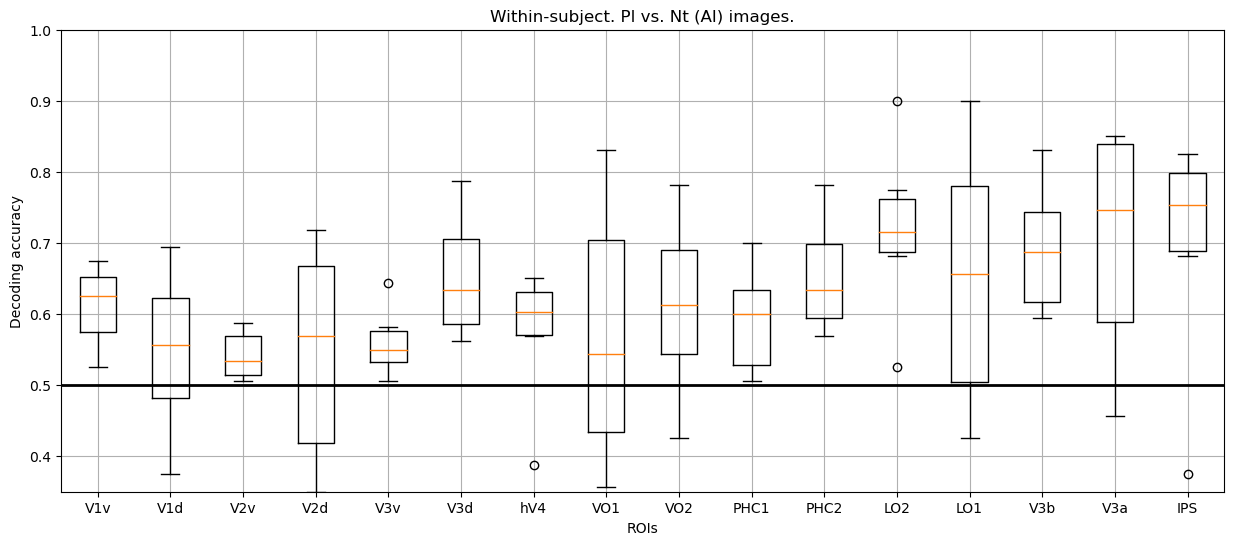

In [45]:
case_id = 2
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(accuracy_rois.T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Within-subject. {decode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 1.0)  # Set the y-axis limits
# Add a thick black line at y=0.5
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

### UP-NT, AI

In [60]:
# Specify the two conditions you want to use for decoding
condition1 = 'unpleasantAI'
condition2 = 'neutralAI'

condition1_idx = conditions.index(condition1)
condition2_idx = conditions.index(condition2)

accuracy_rois = []
for m , (roi_name, roi_mask) in enumerate(roi_masks.items()):
    print(f"Decoding {roi_name}......")
    flat_roi_data = roi_mask.get_fdata()
    # roi_flat = flat_roi_data.flatten(order='F') # this is the same as reshape(1, -1)
    roi_flat = flat_roi_data.flatten()
    indices = np.where(roi_flat)[0]
    data = z_series_wo_sub3[:, :, indices] 

    accuracy_subs = []
    for subject in tqdm(range(data.shape[0])):
        subject_data = data[subject]
        condition1_trials = subject_data[condition1_idx * 100:(condition1_idx + 1) * 100]
        condition2_trials = subject_data[condition2_idx * 100:(condition2_idx + 1) * 100]

        condition1_trials = condition1_trials[:,~np.isnan(condition1_trials[0, :])]
        condition2_trials = condition2_trials[:,~np.isnan(condition2_trials[0, :])]

        # Calculate z-score for condition1_trials and condition2_trials
        # condition1_trials = zscore(condition1_trials, axis=1)
        # condition2_trials = zscore(condition2_trials, axis=1)
        accuracies = []
        for repeat in range(50):
            kf = KFold(n_splits=4, shuffle=True, random_state=repeat)
            condition1_indices = np.arange(condition1_trials.shape[0])
            condition2_indices = np.arange(condition2_trials.shape[0])

            for train_idx, test_idx in kf.split(condition1_indices, condition2_indices):
                train_condition1 = condition1_trials[train_idx]
                train_condition2 = condition2_trials[train_idx]
                test_condition1 = condition1_trials[test_idx]
                test_condition2 = condition2_trials[test_idx]
                # Group the training trials into 3 groups by averaging the first dimension
                train_condition1_averaged_1 = np.array_split(train_condition1, 3, axis=0)
                train_condition1_averaged_2 = [np.mean(group, axis=0) for group in train_condition1_averaged_1]
                train_condition1_averaged = np.array(train_condition1_averaged_2)

                train_condition2_averaged_1 = np.array_split(train_condition2, 3, axis=0)
                train_condition2_averaged_2 = [np.mean(group, axis=0) for group in train_condition2_averaged_1]
                train_condition2_averaged = np.array(train_condition2_averaged_2)

                test_condition1_averaged_1 = np.array_split(test_condition1, 1, axis=0)
                test_condition1_averaged_2 = [np.mean(group, axis=0) for group in test_condition1_averaged_1]
                test_condition1_averaged = np.array(test_condition1_averaged_2)

                test_condition2_averaged_1 = np.array_split(test_condition2,1, axis=0)
                test_condition2_averaged_2 = [np.mean(group, axis=0) for group in test_condition2_averaged_1]
                test_condition2_averaged = np.array(test_condition2_averaged_2)


                # Stack the training data along the first axis
                train_data = np.vstack((train_condition1_averaged, train_condition2_averaged))
                train_labels = np.array([1] * len(train_condition1_averaged) + [0] * len(train_condition2_averaged))

                test_data = np.vstack((test_condition1_averaged, test_condition2_averaged))
                test_labels = np.array([1] * len(test_condition1_averaged) + [0] * len(test_condition2_averaged))

                # Replace NaN values with zeros in train and test data
                # train_data = np.nan_to_num(train_data, copy=False)
                # test_data = np.nan_to_num(test_data, copy=False)

                clf = SVC(kernel='linear')
                clf.fit(train_data, train_labels)
                accuracy = clf.score(test_data, test_labels)
                accuracies.append(accuracy)
        accuracy_subs.append(np.mean(accuracies))

    accuracy_rois.append(np.array(accuracy_subs))
accuracy_self_upnt_ai = np.array(accuracy_rois)

Decoding V1v......


100%|██████████| 6/6 [00:03<00:00,  1.75it/s]


Decoding V1d......


100%|██████████| 6/6 [00:03<00:00,  1.86it/s]


Decoding V2v......


100%|██████████| 6/6 [00:03<00:00,  1.81it/s]


Decoding V2d......


100%|██████████| 6/6 [00:03<00:00,  1.84it/s]


Decoding V3v......


100%|██████████| 6/6 [00:03<00:00,  1.89it/s]


Decoding V3d......


100%|██████████| 6/6 [00:03<00:00,  1.81it/s]


Decoding hV4......


100%|██████████| 6/6 [00:03<00:00,  1.98it/s]


Decoding V3a......


100%|██████████| 6/6 [00:03<00:00,  1.82it/s]


Decoding V3b......


100%|██████████| 6/6 [00:03<00:00,  1.94it/s]


Decoding LO1......


100%|██████████| 6/6 [00:03<00:00,  1.96it/s]


Decoding LO2......


100%|██████████| 6/6 [00:02<00:00,  2.03it/s]


Decoding VO1......


100%|██████████| 6/6 [00:03<00:00,  1.99it/s]


Decoding VO2......


100%|██████████| 6/6 [00:02<00:00,  2.01it/s]


Decoding IPS......


100%|██████████| 6/6 [00:03<00:00,  1.57it/s]


Decoding PHC1......


100%|██████████| 6/6 [00:02<00:00,  2.09it/s]


Decoding PHC2......


100%|██████████| 6/6 [00:02<00:00,  2.06it/s]


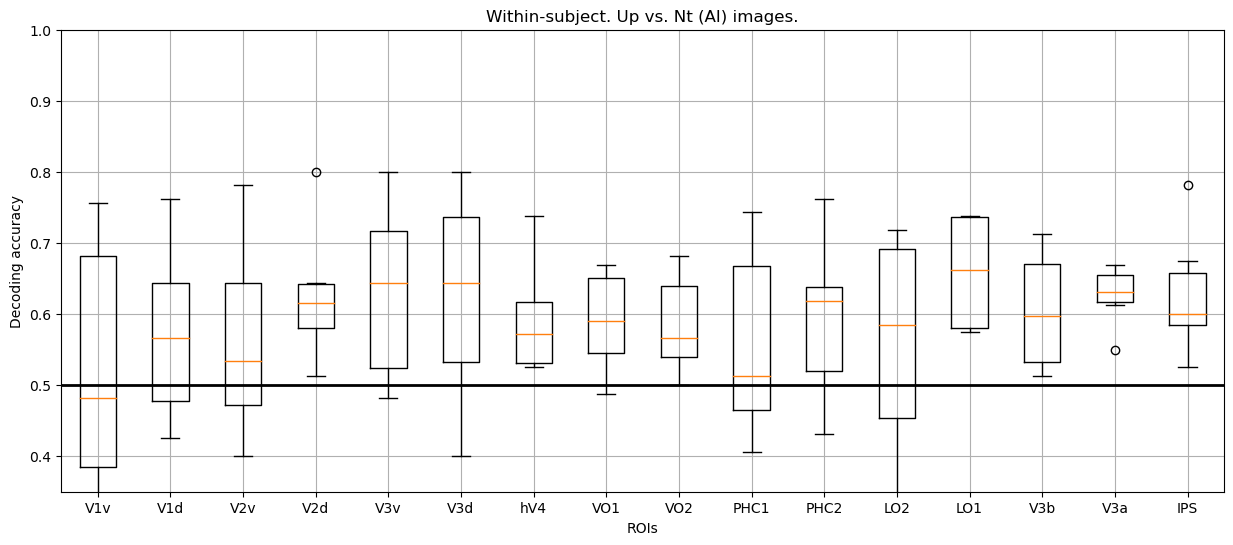

In [43]:
case_id = 3
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(accuracy_rois.T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Within-subject. {decode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 1.0)  # Set the y-axis limits
# Add a thick black line at y=0.5
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

In [64]:
accuracies_self = np.stack((accuracy_self_plnt, accuracy_self_plnt_ai, accuracy_self_upnt, accuracy_self_upnt_ai))
accuracies_self.shape

(4, 16, 6)

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_16648\2396756629.py:30: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)  # Set the y-axis tick labels as percentages


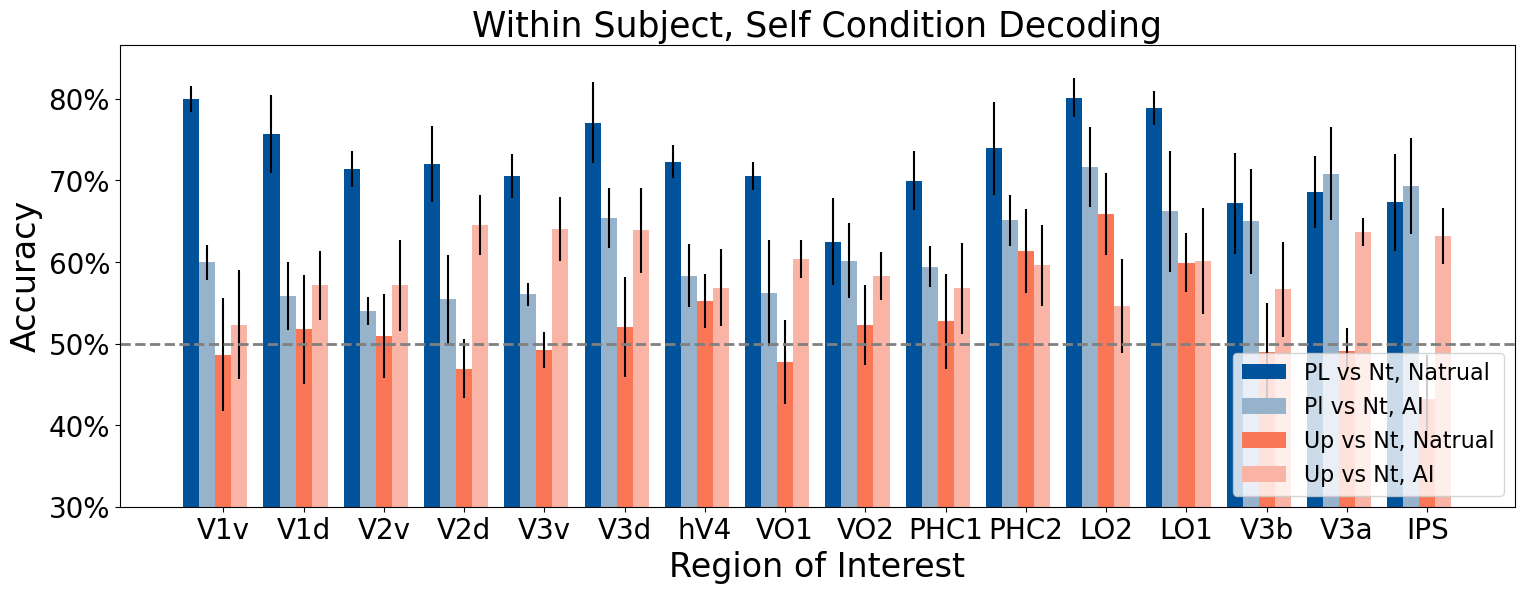

In [120]:
mean_values = np.mean(accuracies_self, axis=2)
std_values = np.std(accuracies_self, axis=2) / np.sqrt(accuracies_self.shape[2])

# Define custom colors for each dataset
colors = [(0/255, 82/255, 155/255),  # RGB values for the first color
          (151/255, 179/255, 203/255),  # RGB values for the second color
          (249/255, 118/255, 86/255),   # RGB values for the third color
          (250/255,180/255, 166/255)]  # RGB values for the fourth color

legends = []
legends.append('PL vs Nt, Natrual')
legends.append('Pl vs Nt, AI')
legends.append('Up vs Nt, Natrual')
legends.append('Up vs Nt, AI')

# Create the bar chart with custom colors
fig, ax = plt.subplots(figsize=(18, 6))
bar_width = 0.2
x = np.arange(16)

for i in range(4):
    ax.bar(x + i * bar_width, mean_values[i], yerr=std_values[i], width=bar_width, label=f'Dataset {i+1}', color=colors[i])

ax.set_xlabel('Region of Interest', fontsize=24)
ax.set_ylabel('Accuracy', fontsize=24)
ax.set_ylim(0.3, None)
ax.set_title('Within Subject, Self Condition Decoding', fontsize=25)
ax.set_xticks(x + 2 * bar_width)
ax.set_xticklabels([f'{roi}' for roi in roi_masks.keys()], fontsize=20)
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)  # Set the y-axis tick labels as percentages
ax.tick_params(axis='y', labelsize=20)
ax.legend(labels = legends, fontsize =16, loc='lower right')

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)  # Add horizontal grey line at y=0.5

plt.show()

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_10560\2396756629.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)  # Set the y-axis tick labels as percentages


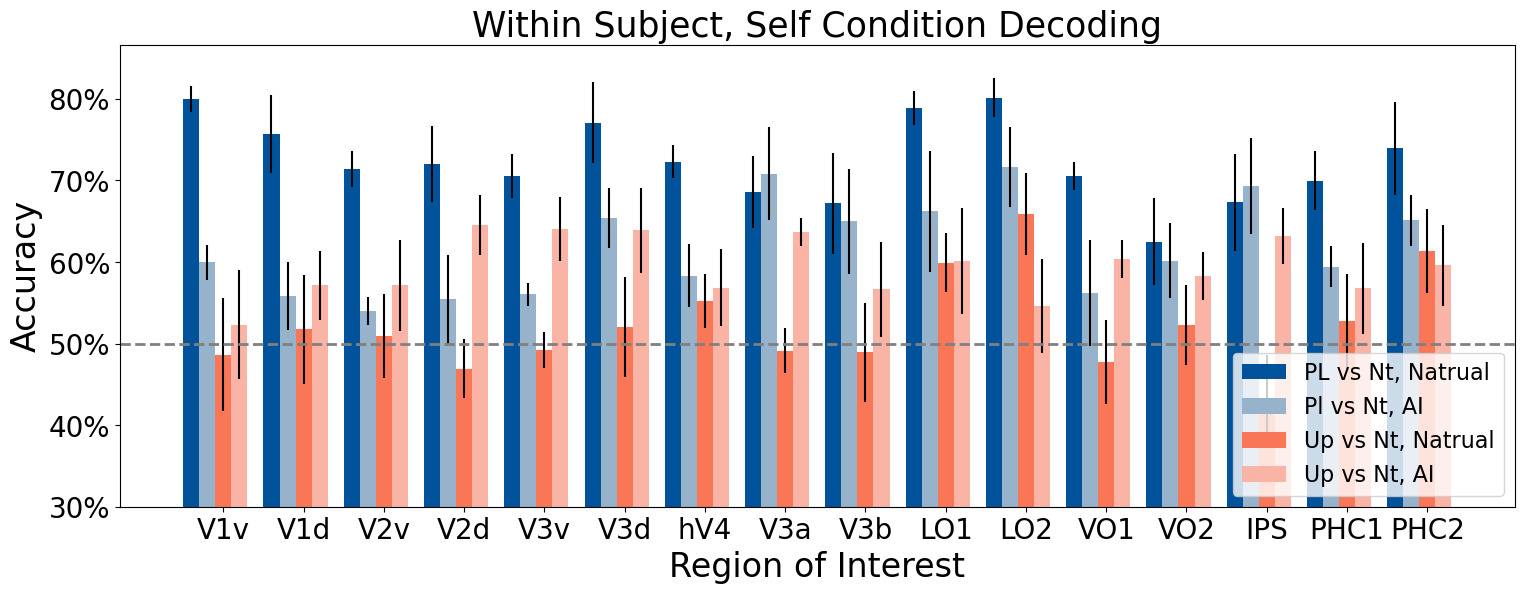

In [65]:
mean_values = np.mean(accuracies_self, axis=2)
std_values = np.std(accuracies_self, axis=2) / np.sqrt(accuracies_self.shape[2])

# Define custom colors for each dataset
colors = [(0/255, 82/255, 155/255),  # RGB values for the first color
          (151/255, 179/255, 203/255),  # RGB values for the second color
          (249/255, 118/255, 86/255),   # RGB values for the third color
          (250/255,180/255, 166/255)]  # RGB values for the fourth color

legends = []
legends.append('PL vs Nt, Natrual')
legends.append('Pl vs Nt, AI')
legends.append('Up vs Nt, Natrual')
legends.append('Up vs Nt, AI')

# Create the bar chart with custom colors
fig, ax = plt.subplots(figsize=(18, 6))
bar_width = 0.2
x = np.arange(16)

for i in range(4):
    ax.bar(x + i * bar_width, mean_values[i], yerr=std_values[i], width=bar_width, label=f'Dataset {i+1}', color=colors[i])

ax.set_xlabel('Region of Interest', fontsize=24)
ax.set_ylabel('Accuracy', fontsize=24)
ax.set_ylim(0.3, None)
ax.set_title('Within Subject, Self Condition Decoding', fontsize=25)
ax.set_xticks(x + 2 * bar_width)
ax.set_xticklabels([f'{roi}' for roi in roi_masks.keys()], fontsize=20)
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)  # Set the y-axis tick labels as percentages
ax.tick_params(axis='y', labelsize=20)
ax.legend(labels = legends, fontsize =16, loc='lower right')

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)  # Add horizontal grey line at y=0.5

plt.show()

## Within-subject, cross-condition Decoding

In [20]:
xdecode_names = []
xdecode_names.append('Pleasant vs. Neutral, trained on natural and tested on AI')
# xdecode_names.append('Pleasant vs. Unpleasant, trained on natural and tested on AI')
xdecode_names.append('Unpleasant vs. Neutral, trained on natural and tested on AI')
xdecode_names.append('Pleasant vs. Neutral, trained on AI and tested on natrual')
# xdecode_names.append('Pleasant vs. Unpleasant, trained on AI and tested on natrual')
xdecode_names.append('Unpleasant vs. Neutral, trained on AI and tested on natrual')

In [21]:
z_series.shape

(7, 600, 79, 95, 79)

In [19]:
z_series_arr = z_series.reshape(z_series.shape[0],z_series.shape[1],-1)
z_series_arr.shape

(7, 600, 592895)

In [22]:
z_series_wo_sub3.shape

(6, 600, 592895)

### PL-NT

In [23]:
# Specify the two conditions you want to use for decoding
condition1 = 'pleasant'
condition2 = 'neutral'
condition1_cross = 'pleasantAI'
condition2_cross = 'neutralAI'

condition1_idx = conditions.index(condition1)
condition2_idx = conditions.index(condition2)
condition1_cross_idx = conditions.index(condition1_cross)
condition2_cross_idx = conditions.index(condition2_cross)

accuracy_rois = []
for m , (roi_name, roi_mask) in enumerate(roi_masks.items()):
    print(f"Decoding {roi_name}......")
    flat_roi_data = roi_mask.get_fdata()
    # roi_flat = flat_roi_data.flatten(order='F') # this is the same as reshape(1, -1)
    roi_flat = flat_roi_data.flatten()
    indices = np.where(roi_flat)[0]
    data = z_series_wo_sub3[:, :, indices] 

    accuracy_subs = []
    for subject in tqdm(range((data.shape[0]))):
        subject_data = data[subject]
        condition1_trials = subject_data[condition1_idx * 100:(condition1_idx + 1) * 100]
        condition2_trials = subject_data[condition2_idx * 100:(condition2_idx + 1) * 100]
        condition1_cross_trials = subject_data[condition1_cross_idx * 100:(condition1_cross_idx + 1) * 100]
        condition2_cross_trials = subject_data[condition2_cross_idx * 100:(condition2_cross_idx + 1) * 100]

        condition1_trials = condition1_trials[:,~np.isnan(condition1_trials[0, :])]
        condition2_trials = condition2_trials[:,~np.isnan(condition2_trials[0, :])]
        condition1_cross_trials = condition1_cross_trials[:,~np.isnan(condition1_cross_trials[0, :])]
        condition2_cross_trials = condition2_cross_trials[:,~np.isnan(condition2_cross_trials[0, :])]

        accuracies = []
        for repeat in range(50):
            train_indices = np.random.permutation(condition1_trials.shape[0])
            group_indices = np.array_split(train_indices, 4)
        
            # Average trials within each group
            train_condition1_averaged = np.array([np.mean(condition1_trials[group_idx, :], axis=0) for group_idx in group_indices])
            train_condition2_averaged = np.array([np.mean(condition2_trials[group_idx, :], axis=0) for group_idx in group_indices])
            # Stack the training data along the first axis
            train_data = np.vstack((train_condition1_averaged, train_condition2_averaged))
            train_labels = np.array([1] * len(train_condition1_averaged) + [0] * len(train_condition2_averaged))

            # Average trials within each group
            test_condition1_averaged = np.array([np.mean(condition1_cross_trials[group_idx, :], axis=0) for group_idx in group_indices])
            test_condition2_averaged = np.array([np.mean(condition2_cross_trials[group_idx, :], axis=0) for group_idx in group_indices])
            # Stack the training data along the first axis
            test_data = np.vstack((test_condition1_averaged, test_condition2_averaged))
            test_labels = np.array([1] * len(test_condition1_averaged) + [0] * len(test_condition2_averaged))

            # Replace NaN values with zeros in train and test data
            # train_data = np.nan_to_num(train_data, copy=False)
            # test_data = np.nan_to_num(test_data, copy=False)

            clf = SVC(kernel='linear')
            clf.fit(train_data, train_labels)
            accuracy = clf.score(test_data, test_labels)
            accuracies.append(accuracy)
        accuracy_subs.append(np.mean(accuracies))

    accuracy_rois.append(np.array(accuracy_subs))
accuracy_cross_plnt = np.array(accuracy_rois)

Decoding V1v......


  0%|          | 0/6 [21:05<?, ?it/s]


KeyboardInterrupt: 

total 2 test avergaed trials

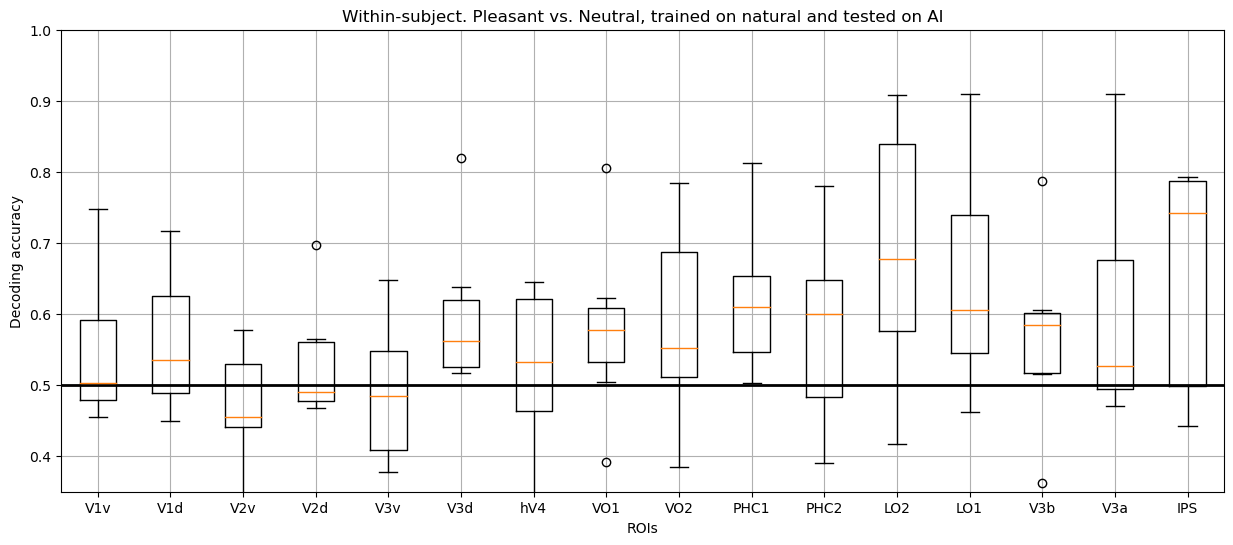

In [30]:
case_id = 0
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(accuracy_rois.T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Within-subject. {xdecode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 1.0)  # Set the y-axis limits
# Add a thick black line at y=0.5
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

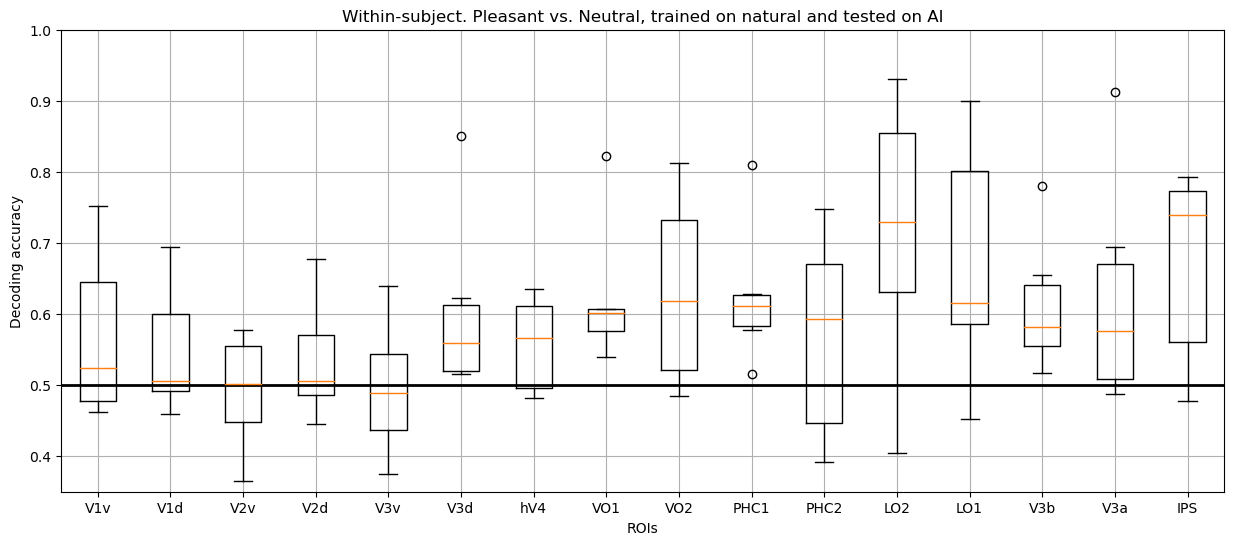

In [40]:
case_id = 0
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(accuracy_rois.T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Within-subject. {xdecode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 1.0)  # Set the y-axis limits
# Add a thick black line at y=0.5
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

### UP-NT

In [107]:
# Specify the two conditions you want to use for decoding
condition1 = 'unpleasant'
condition2 = 'neutral'
condition1_cross = 'unpleasantAI'
condition2_cross = 'neutralAI'

condition1_idx = conditions.index(condition1)
condition2_idx = conditions.index(condition2)
condition1_cross_idx = conditions.index(condition1_cross)
condition2_cross_idx = conditions.index(condition2_cross)

accuracy_rois = []
for m , (roi_name, roi_mask) in enumerate(roi_masks.items()):
    print(f"Decoding {roi_name}......")
    flat_roi_data = roi_mask.get_fdata()
    # roi_flat = flat_roi_data.flatten(order='F') # this is the same as reshape(1, -1)
    roi_flat = flat_roi_data.flatten()
    indices = np.where(roi_flat)[0]
    data = z_series_wo_sub3[:, :, indices] 

    accuracy_subs = []
    for subject in tqdm(range((data.shape[0]))):
        subject_data = data[subject]
        condition1_trials = subject_data[condition1_idx * 100:(condition1_idx + 1) * 100]
        condition2_trials = subject_data[condition2_idx * 100:(condition2_idx + 1) * 100]
        condition1_cross_trials = subject_data[condition1_cross_idx * 100:(condition1_cross_idx + 1) * 100]
        condition2_cross_trials = subject_data[condition2_cross_idx * 100:(condition2_cross_idx + 1) * 100]

        condition1_trials = condition1_trials[:,~np.isnan(condition1_trials[0, :])]
        condition2_trials = condition2_trials[:,~np.isnan(condition2_trials[0, :])]
        condition1_cross_trials = condition1_cross_trials[:,~np.isnan(condition1_cross_trials[0, :])]
        condition2_cross_trials = condition2_cross_trials[:,~np.isnan(condition2_cross_trials[0, :])]

        accuracies = []
        for repeat in range(50):
            train_indices = np.random.permutation(condition1_trials.shape[0])
            group_indices = np.array_split(train_indices, 4)
        
            # Average trials within each group
            train_condition1_averaged = np.array([np.mean(condition1_trials[group_idx, :], axis=0) for group_idx in group_indices])
            train_condition2_averaged = np.array([np.mean(condition2_trials[group_idx, :], axis=0) for group_idx in group_indices])
            # Stack the training data along the first axis
            train_data = np.vstack((train_condition1_averaged, train_condition2_averaged))
            train_labels = np.array([1] * len(train_condition1_averaged) + [0] * len(train_condition2_averaged))

            # Average trials within each group
            test_condition1_averaged = np.array([np.mean(condition1_cross_trials[group_idx, :], axis=0) for group_idx in group_indices])
            test_condition2_averaged = np.array([np.mean(condition2_cross_trials[group_idx, :], axis=0) for group_idx in group_indices])
            # Stack the training data along the first axis
            test_data = np.vstack((test_condition1_averaged, test_condition2_averaged))
            test_labels = np.array([1] * len(test_condition1_averaged) + [0] * len(test_condition2_averaged))

            # Replace NaN values with zeros in train and test data
            # train_data = np.nan_to_num(train_data, copy=False)
            # test_data = np.nan_to_num(test_data, copy=False)

            clf = SVC(kernel='linear')
            clf.fit(train_data, train_labels)
            accuracy = clf.score(test_data, test_labels)
            accuracies.append(accuracy)
        accuracy_subs.append(np.mean(accuracies))

    accuracy_rois.append(np.array(accuracy_subs))
accuracy_cross_upnt = np.array(accuracy_rois)

Decoding V1v......


100%|██████████| 6/6 [00:00<00:00,  7.15it/s]


Decoding V1d......


100%|██████████| 6/6 [00:00<00:00,  6.81it/s]


Decoding V2v......


100%|██████████| 6/6 [00:00<00:00,  6.69it/s]


Decoding V2d......


100%|██████████| 6/6 [00:00<00:00,  8.31it/s]


Decoding V3v......


100%|██████████| 6/6 [00:00<00:00,  7.18it/s]


Decoding V3d......


100%|██████████| 6/6 [00:00<00:00,  7.47it/s]


Decoding hV4......


100%|██████████| 6/6 [00:00<00:00,  7.23it/s]


Decoding VO1......


100%|██████████| 6/6 [00:00<00:00, 11.15it/s]


Decoding VO2......


100%|██████████| 6/6 [00:00<00:00, 10.64it/s]


Decoding PHC1......


100%|██████████| 6/6 [00:00<00:00,  7.32it/s]


Decoding PHC2......


100%|██████████| 6/6 [00:00<00:00,  8.21it/s]


Decoding LO2......


100%|██████████| 6/6 [00:00<00:00, 12.25it/s]


Decoding LO1......


100%|██████████| 6/6 [00:00<00:00,  8.52it/s]


Decoding V3b......


100%|██████████| 6/6 [00:00<00:00, 10.56it/s]


Decoding V3a......


100%|██████████| 6/6 [00:00<00:00,  8.32it/s]


Decoding IPS......


100%|██████████| 6/6 [00:00<00:00,  6.59it/s]


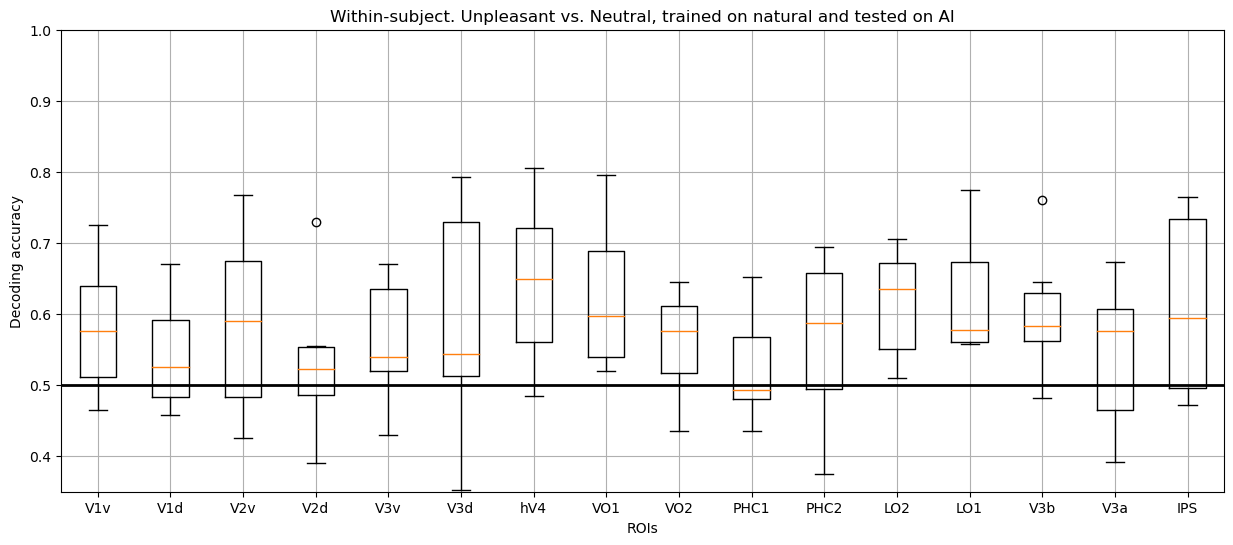

In [42]:
case_id = 1
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(accuracy_rois.T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Within-subject. {xdecode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 1.0)  # Set the y-axis limits
# Add a thick black line at y=0.5
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

### PL-NT, trained on AI and tested on NA

In [108]:
# Specify the two conditions you want to use for decoding
condition1 = 'pleasantAI'
condition2 = 'neutralAI'
condition1_cross = 'pleasant'
condition2_cross = 'neutral'

condition1_idx = conditions.index(condition1)
condition2_idx = conditions.index(condition2)
condition1_cross_idx = conditions.index(condition1_cross)
condition2_cross_idx = conditions.index(condition2_cross)

accuracy_rois = []
for m , (roi_name, roi_mask) in enumerate(roi_masks.items()):
    print(f"Decoding {roi_name}......")
    flat_roi_data = roi_mask.get_fdata()
    # roi_flat = flat_roi_data.flatten(order='F') # this is the same as reshape(1, -1)
    roi_flat = flat_roi_data.flatten()
    indices = np.where(roi_flat)[0]
    data = z_series_wo_sub3[:, :, indices] 

    accuracy_subs = []
    for subject in tqdm(range((data.shape[0]))):
        subject_data = data[subject]
        condition1_trials = subject_data[condition1_idx * 100:(condition1_idx + 1) * 100]
        condition2_trials = subject_data[condition2_idx * 100:(condition2_idx + 1) * 100]
        condition1_cross_trials = subject_data[condition1_cross_idx * 100:(condition1_cross_idx + 1) * 100]
        condition2_cross_trials = subject_data[condition2_cross_idx * 100:(condition2_cross_idx + 1) * 100]

        condition1_trials = condition1_trials[:,~np.isnan(condition1_trials[0, :])]
        condition2_trials = condition2_trials[:,~np.isnan(condition2_trials[0, :])]
        condition1_cross_trials = condition1_cross_trials[:,~np.isnan(condition1_cross_trials[0, :])]
        condition2_cross_trials = condition2_cross_trials[:,~np.isnan(condition2_cross_trials[0, :])]

        accuracies = []
        for repeat in range(50):
            train_indices = np.random.permutation(condition1_trials.shape[0])
            group_indices = np.array_split(train_indices, 4)
        
            # Average trials within each group
            train_condition1_averaged = np.array([np.mean(condition1_trials[group_idx, :], axis=0) for group_idx in group_indices])
            train_condition2_averaged = np.array([np.mean(condition2_trials[group_idx, :], axis=0) for group_idx in group_indices])
            # Stack the training data along the first axis
            train_data = np.vstack((train_condition1_averaged, train_condition2_averaged))
            train_labels = np.array([1] * len(train_condition1_averaged) + [0] * len(train_condition2_averaged))

            # Average trials within each group
            test_condition1_averaged = np.array([np.mean(condition1_cross_trials[group_idx, :], axis=0) for group_idx in group_indices])
            test_condition2_averaged = np.array([np.mean(condition2_cross_trials[group_idx, :], axis=0) for group_idx in group_indices])
            # Stack the training data along the first axis
            test_data = np.vstack((test_condition1_averaged, test_condition2_averaged))
            test_labels = np.array([1] * len(test_condition1_averaged) + [0] * len(test_condition2_averaged))

            # Replace NaN values with zeros in train and test data
            # train_data = np.nan_to_num(train_data, copy=False)
            # test_data = np.nan_to_num(test_data, copy=False)

            clf = SVC(kernel='linear')
            clf.fit(train_data, train_labels)
            accuracy = clf.score(test_data, test_labels)
            accuracies.append(accuracy)
        accuracy_subs.append(np.mean(accuracies))

    accuracy_rois.append(np.array(accuracy_subs))
accuracy_cross_plnt_ai = np.array(accuracy_rois)

Decoding V1v......


100%|██████████| 6/6 [00:00<00:00,  7.05it/s]


Decoding V1d......


100%|██████████| 6/6 [00:01<00:00,  5.90it/s]


Decoding V2v......


100%|██████████| 6/6 [00:00<00:00,  7.99it/s]


Decoding V2d......


100%|██████████| 6/6 [00:00<00:00,  8.60it/s]


Decoding V3v......


100%|██████████| 6/6 [00:00<00:00,  8.25it/s]


Decoding V3d......


100%|██████████| 6/6 [00:00<00:00,  9.20it/s]


Decoding hV4......


100%|██████████| 6/6 [00:00<00:00, 10.17it/s]


Decoding VO1......


100%|██████████| 6/6 [00:00<00:00, 12.11it/s]


Decoding VO2......


100%|██████████| 6/6 [00:00<00:00, 10.08it/s]


Decoding PHC1......


100%|██████████| 6/6 [00:00<00:00,  9.13it/s]


Decoding PHC2......


100%|██████████| 6/6 [00:00<00:00, 10.12it/s]


Decoding LO2......


100%|██████████| 6/6 [00:00<00:00, 10.64it/s]


Decoding LO1......


100%|██████████| 6/6 [00:01<00:00,  4.02it/s]


Decoding V3b......


100%|██████████| 6/6 [00:00<00:00,  8.79it/s]


Decoding V3a......


100%|██████████| 6/6 [00:00<00:00,  7.57it/s]


Decoding IPS......


100%|██████████| 6/6 [00:00<00:00,  7.76it/s]


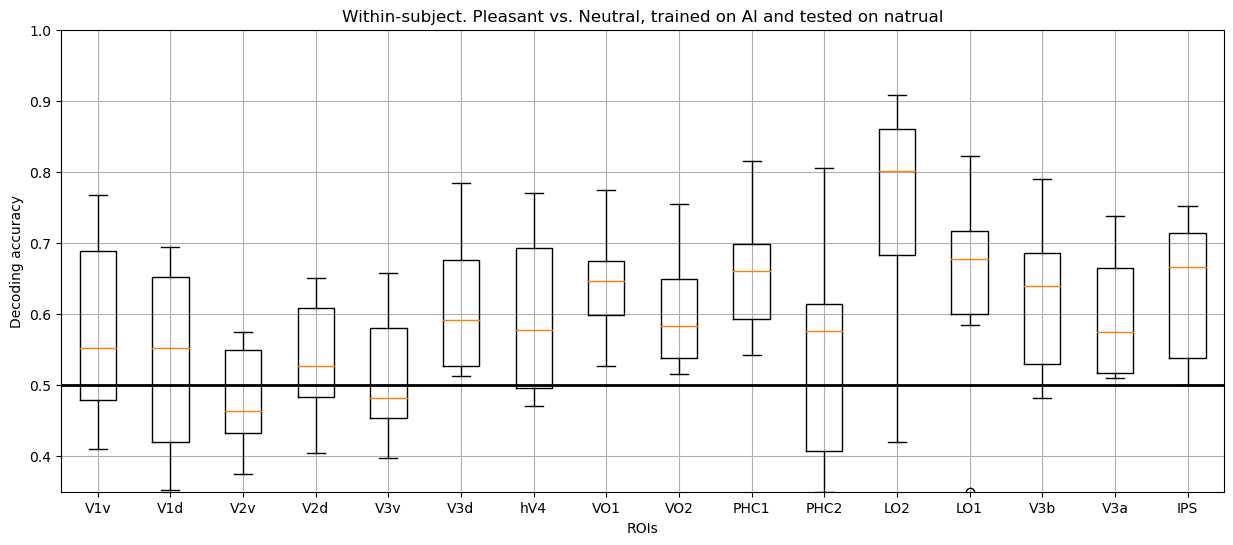

In [44]:
case_id = 2
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(accuracy_rois.T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Within-subject. {xdecode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 1.0)  # Set the y-axis limits
# Add a thick black line at y=0.5
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

### UP-NT, trained on AI and tested on NA

In [109]:
# Specify the two conditions you want to use for decoding
condition1 = 'unpleasantAI'
condition2 = 'neutralAI'
condition1_cross = 'unpleasant'
condition2_cross = 'neutral'

condition1_idx = conditions.index(condition1)
condition2_idx = conditions.index(condition2)
condition1_cross_idx = conditions.index(condition1_cross)
condition2_cross_idx = conditions.index(condition2_cross)

accuracy_rois = []
for m , (roi_name, roi_mask) in enumerate(roi_masks.items()):
    print(f"Decoding {roi_name}......")
    flat_roi_data = roi_mask.get_fdata()
    # roi_flat = flat_roi_data.flatten(order='F') # this is the same as reshape(1, -1)
    roi_flat = flat_roi_data.flatten()
    indices = np.where(roi_flat)[0]
    data = z_series_wo_sub3[:, :, indices] 

    accuracy_subs = []
    for subject in tqdm(range((data.shape[0]))):
        subject_data = data[subject]
        condition1_trials = subject_data[condition1_idx * 100:(condition1_idx + 1) * 100]
        condition2_trials = subject_data[condition2_idx * 100:(condition2_idx + 1) * 100]
        condition1_cross_trials = subject_data[condition1_cross_idx * 100:(condition1_cross_idx + 1) * 100]
        condition2_cross_trials = subject_data[condition2_cross_idx * 100:(condition2_cross_idx + 1) * 100]

        condition1_trials = condition1_trials[:,~np.isnan(condition1_trials[0, :])]
        condition2_trials = condition2_trials[:,~np.isnan(condition2_trials[0, :])]
        condition1_cross_trials = condition1_cross_trials[:,~np.isnan(condition1_cross_trials[0, :])]
        condition2_cross_trials = condition2_cross_trials[:,~np.isnan(condition2_cross_trials[0, :])]

        accuracies = []
        for repeat in range(50):
            train_indices = np.random.permutation(condition1_trials.shape[0])
            group_indices = np.array_split(train_indices, 4)
        
            # Average trials within each group
            train_condition1_averaged = np.array([np.mean(condition1_trials[group_idx, :], axis=0) for group_idx in group_indices])
            train_condition2_averaged = np.array([np.mean(condition2_trials[group_idx, :], axis=0) for group_idx in group_indices])
            # Stack the training data along the first axis
            train_data = np.vstack((train_condition1_averaged, train_condition2_averaged))
            train_labels = np.array([1] * len(train_condition1_averaged) + [0] * len(train_condition2_averaged))

            # Average trials within each group
            test_condition1_averaged = np.array([np.mean(condition1_cross_trials[group_idx, :], axis=0) for group_idx in group_indices])
            test_condition2_averaged = np.array([np.mean(condition2_cross_trials[group_idx, :], axis=0) for group_idx in group_indices])
            # Stack the training data along the first axis
            test_data = np.vstack((test_condition1_averaged, test_condition2_averaged))
            test_labels = np.array([1] * len(test_condition1_averaged) + [0] * len(test_condition2_averaged))

            # Replace NaN values with zeros in train and test data
            # train_data = np.nan_to_num(train_data, copy=False)
            # test_data = np.nan_to_num(test_data, copy=False)

            clf = SVC(kernel='linear')
            clf.fit(train_data, train_labels)
            accuracy = clf.score(test_data, test_labels)
            accuracies.append(accuracy)
        accuracy_subs.append(np.mean(accuracies))

    accuracy_rois.append(np.array(accuracy_subs))
accuracy_cross_upnt_ai = np.array(accuracy_rois)

Decoding V1v......


100%|██████████| 6/6 [00:00<00:00,  6.63it/s]


Decoding V1d......


100%|██████████| 6/6 [00:00<00:00,  7.02it/s]


Decoding V2v......


100%|██████████| 6/6 [00:00<00:00,  7.71it/s]


Decoding V2d......


100%|██████████| 6/6 [00:00<00:00,  8.67it/s]


Decoding V3v......


100%|██████████| 6/6 [00:00<00:00,  9.13it/s]


Decoding V3d......


100%|██████████| 6/6 [00:00<00:00,  9.75it/s]


Decoding hV4......


100%|██████████| 6/6 [00:00<00:00, 10.60it/s]


Decoding VO1......


100%|██████████| 6/6 [00:00<00:00, 12.90it/s]


Decoding VO2......


100%|██████████| 6/6 [00:00<00:00, 10.61it/s]


Decoding PHC1......


100%|██████████| 6/6 [00:00<00:00, 11.88it/s]


Decoding PHC2......


100%|██████████| 6/6 [00:00<00:00, 12.05it/s]


Decoding LO2......


100%|██████████| 6/6 [00:00<00:00, 13.13it/s]


Decoding LO1......


100%|██████████| 6/6 [00:00<00:00, 10.71it/s]


Decoding V3b......


100%|██████████| 6/6 [00:00<00:00, 10.83it/s]


Decoding V3a......


100%|██████████| 6/6 [00:00<00:00,  9.72it/s]


Decoding IPS......


100%|██████████| 6/6 [00:00<00:00,  7.93it/s]


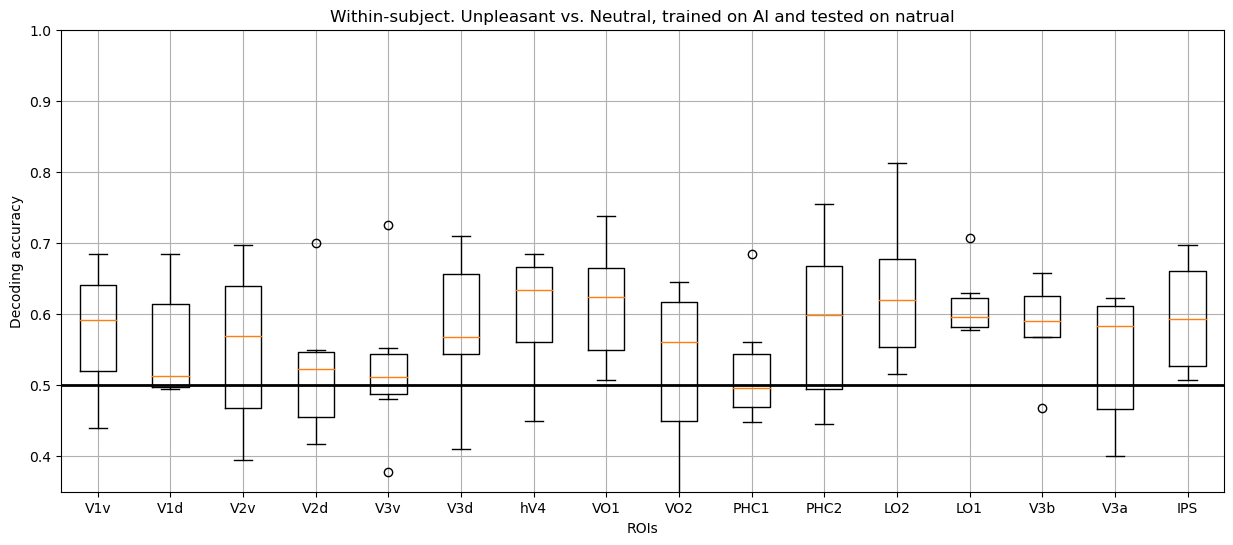

In [46]:
case_id = 3
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(accuracy_rois.T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Within-subject. {xdecode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 1.0)  # Set the y-axis limits
# Add a thick black line at y=0.5
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

In [111]:
accuracies_cross = np.stack((accuracy_cross_plnt, accuracy_cross_plnt_ai, accuracy_cross_upnt, accuracy_cross_upnt_ai))
accuracies_cross.shape

(4, 16, 6)

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_16648\1258925033.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)  # Set the y-axis tick labels as percentages


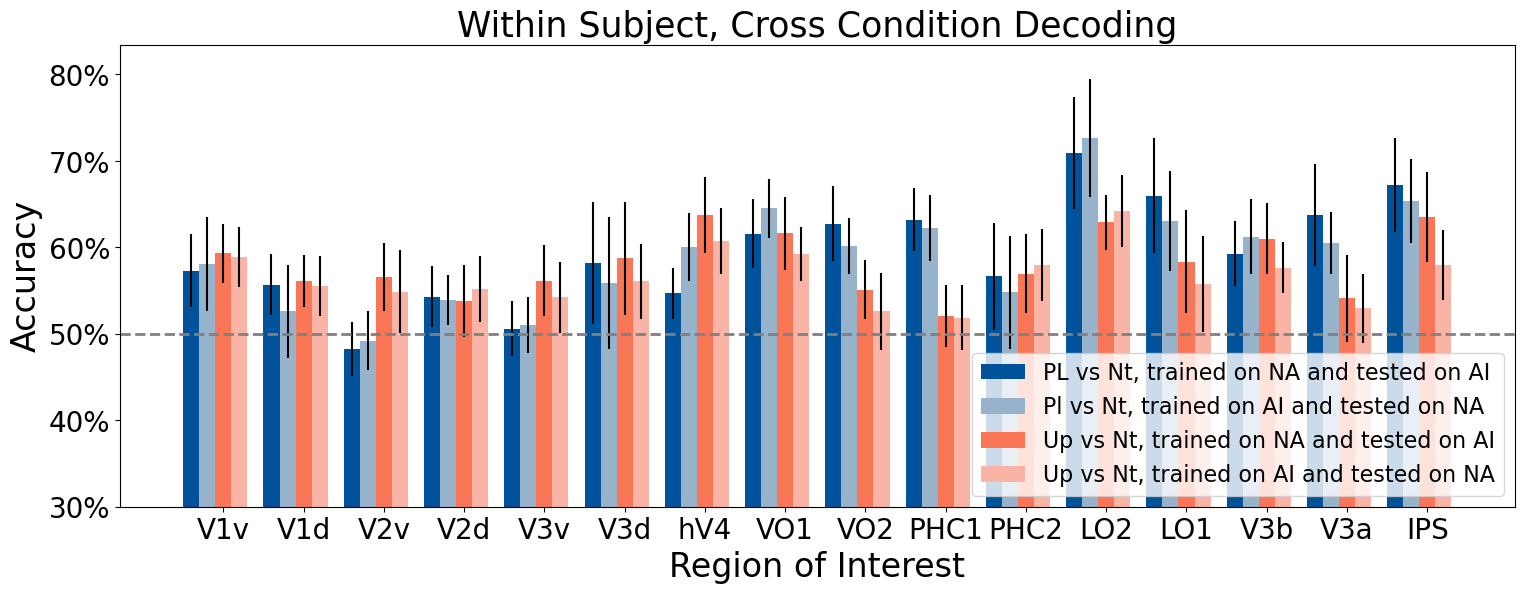

In [121]:
mean_values = np.mean(accuracies_cross, axis=2)
std_values = np.std(accuracies_cross, axis=2) / np.sqrt(accuracies_cross.shape[2])

# Define custom colors for each dataset
colors = [(0/255, 82/255, 155/255),  # RGB values for the first color
          (151/255, 179/255, 203/255),  # RGB values for the second color
          (249/255, 118/255, 86/255),   # RGB values for the third color
          (250/255,180/255, 166/255)]  # RGB values for the fourth color

legends = []
legends.append('PL vs Nt, trained on NA and tested on AI')
legends.append('Pl vs Nt, trained on AI and tested on NA')
legends.append('Up vs Nt, trained on NA and tested on AI')
legends.append('Up vs Nt, trained on AI and tested on NA')

# Create the bar chart with custom colors
fig, ax = plt.subplots(figsize=(18, 6))
bar_width = 0.2
x = np.arange(16)

for i in range(4):
    ax.bar(x + i * bar_width, mean_values[i], yerr=std_values[i], width=bar_width, label=f'Dataset {i+1}', color=colors[i])


ax.set_xlabel('Region of Interest', fontsize=24)
ax.set_ylabel('Accuracy', fontsize=24)
ax.set_ylim(0.3, None)
ax.set_title('Within Subject, Cross Condition Decoding', fontsize=25)
ax.set_xticks(x + 2 * bar_width)
ax.set_xticklabels([f'{roi}' for roi in roi_masks.keys()], fontsize=20)
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)  # Set the y-axis tick labels as percentages
ax.tick_params(axis='y', labelsize=20)
ax.legend(labels = legends, fontsize =16, loc='lower right')

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)  # Add horizontal grey line at y=0.5

plt.show()